In [2]:
%load_ext autoreload
%autoreload 2

from scipy import interpolate
from scipy import stats
from datetime import timedelta
import pytz
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib import gridspec
import pandas as pd
import os, sys
import geopandas as gpd
from pyproj import CRS
import pickle

sys.path.insert(0, os.pardir)
from coastsat import SDS_tools, SDS_download, SDS_preprocess, SDS_shoreline, SDS_transects
from experiments.general_utils import spectral_unmixing as su, indices, thresholding, modified_coastsat
from osgeo import gdal

import warnings
warnings.filterwarnings("ignore")

data_dir = r"C:\Users\avanever\Documents\CoastSatProject\Experiments\data\narrabeen"

In [3]:
# read the csv file
fp_datasets = os.path.join(data_dir,'Narrabeen_Profiles.csv')
df = pd.read_csv(fp_datasets)
pf_names = list(np.unique(df['Profile ID']))

# select contour level
contour_level = 0.7

# initialise topo_profiles structure
topo_profiles = dict([])
for i in range(len(pf_names)):
     # read dates
    df_pf = df.loc[df['Profile ID'] == pf_names[i]]
    dates_str = df['Date']
    dates_unique = np.unique(dates_str)
    # loop through dates
    topo_profiles[pf_names[i]] = {'dates':[],'chainages':[]}
    for date in dates_unique:
        # extract chainage and elevation for that date
        df_date = df_pf.loc[dates_str == date]
        chainages = np.array(df_date['Chainage'])
        elevations = np.array(df_date['Elevation'])
        if len(chainages) == 0: continue
        # use interpolation to extract the chainage at the contour level
        f = interpolate.interp1d(elevations, chainages, bounds_error=False)
        chainage_contour_level = f(contour_level)
        topo_profiles[pf_names[i]]['chainages'].append(chainage_contour_level)
        date_utc = pytz.utc.localize(datetime.strptime(date,'%Y-%m-%d'))
        topo_profiles[pf_names[i]]['dates'].append(date_utc)

# # plot time-series
# fig = plt.figure(figsize=[15,8], tight_layout=True)
# gs = gridspec.GridSpec(len(topo_profiles),1)
# gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95, hspace=0.05)
# for i,key in enumerate(topo_profiles.keys()):
#     ax = fig.add_subplot(gs[i,0])
#     ax.grid(linestyle=':', color='0.5')
#     ax.plot(topo_profiles[key]['dates'], topo_profiles[key]['chainages'], '-o', ms=4, mfc='w')
#     ax.set_ylabel('distance [m]', fontsize=12)
#     ax.text(0.5,0.95, key, bbox=dict(boxstyle="square", ec='k',fc='w'), ha='center',
#             va='top', transform=ax.transAxes, fontsize=14)  

# save a .pkl file
narra_survey_ts_path = os.path.join(r"C:\Users\avanever\Documents\CoastSatProject\Experiments\data\narrabeen\data", 'Narrabeen_ts_07m.pkl')
with open(narra_survey_ts_path, 'wb') as f:
    pickle.dump(topo_profiles, f)

In [4]:
# region of interest (longitude, latitude)
polygon = [[[151.2957545, -33.7012561],
            [151.297557, -33.7388075],
            [151.312234, -33.7390216],
            [151.311204, -33.701399],
            [151.2957545, -33.7012561]]]
# it's recommended to convert the polygon to the smallest rectangle (sides parallel to coordinate axes)       
polygon = SDS_tools.smallest_rectangle(polygon)
# date range
dates = ['1984-01-01', '2024-10-01']
sat_list = ['L5', 'L7', 'L8']
# name of the site
sitename = 'NARRA'
# directory where the data will be stored
filepath = os.path.join(data_dir, 'data')
inputs = {'polygon': polygon, 'dates': dates, 'sat_list': sat_list,
          'sitename': sitename, 'filepath':filepath,
          'transect_geojson': r"C:\Users\avanever\Documents\CoastSatProject\Experiments\data\narrabeen\data\NARRA\narra_transects.geojson"}

settings = {

    # preprocessing
    "cloud_mask_issue": False, # switch this parameter to True if sand pixels are masked (in black) on many images
    "pan_off": False, # True to switch pansharpening off for Landsat 7/8/9 imagery
    "s2cloudless_prob": 60, # Threshold to identify cloud pixels in the s2cloudless probability mask (s2 cloud mask is not 1 and 0, but a probability [0,100))

    # extraction settings
    "cloud_thresh": 0.5, # percentage of image that can be covered by cloud
    "dist_clouds": 30, # distance in metres defining a buffer around cloudy pixels where the shoreline cannot be mapped
    "min_length_sl": 500, # minimum length of shoreline perimeter to be kept (in meters)
    "max_dist_ref" : 250, # maximum distance from the reference shoreline in meters

    # manual detection (untested)
    "check_detection": False, # lets user manually accept/reject the mapped shorelines
    "adjust_detection": False, # lets user adjust the detected shorelines with a slide bar.

    # classifier (only used for very sandy beaches)
    "min_beach_area": 1000, # minimum number of pixels that have to be connected to belong to the SAND class
    "sand_color": "default", # classification model: 'default', 'latest', 'dark' (for grey/black sand beaches) or 'bright' (for white sand beaches)

    # plotting
    "plot_mndwi": False, # plot histograms of MNDWI values for each image
    "save_detection_plots": True, # plot RGB, pixel classification, MNDWI, and extracted shoreline
    "plot_cloud_cover": False, # plot histogram of cloud cover percentages of each image

    "inputs": inputs,
    "output_epsg": 28356,
}

transect_settings = {

    # collider settings (note how these interact with max_dist_ref)
    "along_dist": 35, # how far a point can be orthogonally to transect line
    "past_dist": 300, # distance a shoreline points can be past end of transect and be counted as an intersection
    "min_chainage": -150, # furthest landward of the transect origin that an intersection is accepted
    
    # dispersion thresholds
    "min_points": 3, # minimum number of points to calculate an intersections
    "max_std": 15, # maximum standard deviation of intersections per transect (exceptions are dealt with according to multiple_inter)
    "max_range": 30, # maximum range of intersections per transect (exceptions are dealt with according to multiple_inter)

    # clustering shoreline selection settings
    "cluster_intersection_selection": True, # use clustering intersection algorithm
    "clustering_threshold": 20, # minimum gap between consecutive intersections needed to start new cluster
    "cloud_filtering": True, # throw away points when a cloud might be covering the correct shoreline
    
    # clustering shoreline selection plotting
    "transects_to_plot": [], # plot all intersections for transects with these names
    "plot_entire_shoreline": False, # add plot to intersection images showing the entire shoreline to provide more context
    "plot_1d": True, # add plot to intersection images showing projected intersection points
    "plot_sat": False,

    "plot_n_clusters": False, # plot number of clusters and transect class on time series for each transect
    "plot_rejection_counts": False, # plot why intersections were rejected, for each transect and each shoreline (before outlier rejection)

    "sitename": inputs["sitename"],
    "output_dir": inputs["filepath"]
}

settings['reference_shoreline'] = SDS_preprocess.get_reference_sl_from_geojson(
        r"C:\Users\avanever\Documents\CoastSatProject\Experiments\data\narrabeen\data\NARRA\NARRA_reference_shoreline.geojson",
        settings["output_epsg"],
    )
settings['max_dist_ref'] = 100 # max distance (in meters) allowed from the reference shoreline

transects = SDS_tools.transects_from_geojson(inputs["transect_geojson"])

Reference shorelines found in GeoJSON. Loading coordinates for each feature.
5 transects have been loaded 
coordinates are in epsg:28356


In [18]:
# metadata = modified_coastsat.retrieve_images(inputs)
metadata = SDS_download.get_metadata(inputs)

In [28]:
output = modified_coastsat.extract_shorelines(metadata, settings)

Mapping shorelines:
5 transects have been loaded 
coordinates are in epsg:28356
L5: 100%
    214 shorelines extracted, 54 skipped due to cloud cover, 68 skipped due to no data, 2 skipped due to errors, 0 skipped by user.
    Shoreline buffer computed 4 times and cached 212 times
L7: 100%
    278 shorelines extracted, 125 skipped due to cloud cover, 61 skipped due to no data, 0 skipped due to errors, 0 skipped by user.
    Shoreline buffer computed 1 times and cached 277 times
L8: 100%
    265 shorelines extracted, 51 skipped due to cloud cover, 137 skipped due to no data, 0 skipped due to errors, 0 skipped by user.
    Shoreline buffer computed 2 times and cached 263 times
131 duplicate photos removed
0 images with bad georeferencing removed


In [29]:
# output = cs_output
cross_distance = SDS_transects.compute_intersection_QC(output, transects, transect_settings) 

# remove outliers in the time-series (coastal despiking)
settings_outliers = {'max_cross_change':   40,             # maximum cross-shore change observable between consecutive timesteps
                     'otsu_threshold':     [-.5,1],        # min and max intensity threshold use for contouring the shoreline
                     'plot_fig':           False,           # whether to plot the intermediate steps
                    }
cross_distance = SDS_transects.reject_outliers(cross_distance,output,settings_outliers)

Processing shoreline 626 out of 626...
Cleaning time series data (removing outliers)...
--> NA1: Removed 7 outliers
--> NA2: Removed 7 outliers
--> NA3: Removed 1 outliers
--> NA4: Removed 0 outliers
--> NA5: Removed 2 outliers


In [30]:
# load survey data
with open(narra_survey_ts_path, 'rb') as f:
    gt = pickle.load(f)
# change names to mach surveys
for i,key in enumerate(list(cross_distance.keys())):
    key_gt = list(gt.keys())[i]
    cross_distance[key_gt] = cross_distance.pop(key)

# set parameters for comparing the two time-series
sett = {'min_days':3,   # numbers of days difference under which to use nearest neighbour interpolation
        'max_days':10,  # maximum number of days difference to do a comparison
        'binwidth':3,   # binwidth for histogram plotting
        'lims':[-50,50] # cross-shore change limits for plotting purposes
       }

# initialise variables
chain_sat_all = []
chain_sur_all = [] 
satnames_all = []  
for key in cross_distance.keys():
    
    # remove nans
    chainage = cross_distance[key]
    idx_nan = np.isnan(chainage)
    dates_nonans = [output['dates'][k] for k in np.where(~idx_nan)[0]]
    satnames_nonans = [output['satname'][k] for k in np.where(~idx_nan)[0]]
    chain_nonans = chainage[~idx_nan]
    
    chain_sat_dm = chain_nonans
    chain_sur_dm = gt[key]['chainages']
    
    # interpolate surveyed data around satellite data
    chain_int = np.nan*np.ones(len(dates_nonans))
    for k,date in enumerate(dates_nonans):
        # compute the days distance for each satellite date 
        days_diff = np.array([ (_ - date).days for _ in gt[key]['dates']])
        # if nothing within 10 days put a nan
        if np.min(np.abs(days_diff)) > sett['max_days']:
            chain_int[k] = np.nan
        else:
            # if a point within 3 days, take that point (no interpolation)
            if np.min(np.abs(days_diff)) < sett['min_days']:
                idx_closest = np.where(np.abs(days_diff) == np.min(np.abs(days_diff)))
                chain_int[k] = float(gt[key]['chainages'][idx_closest[0][0]])
            else: # otherwise, between 3 and 10 days, interpolate between the 2 closest points
                if sum(days_diff > 0) == 0:
                    break
                idx_after = np.where(days_diff > 0)[0][0]
                idx_before = idx_after - 1
                x = [gt[key]['dates'][idx_before].toordinal() , gt[key]['dates'][idx_after].toordinal()]
                y = [gt[key]['chainages'][idx_before], gt[key]['chainages'][idx_after]]
                f = interpolate.interp1d(x, y,bounds_error=True)
                chain_int[k] = float(f(date.toordinal()))
    
    # remove nans again
    idx_nan = np.isnan(chain_int)
    chain_sat = chain_nonans[~idx_nan]
    chain_sur = chain_int[~idx_nan]
    dates_sat = [dates_nonans[k] for k in np.where(~idx_nan)[0]]
    satnames = [satnames_nonans[k] for k in np.where(~idx_nan)[0]]
    chain_sat_all = np.append(chain_sat_all,chain_sat)
    chain_sur_all = np.append(chain_sur_all,chain_sur)
    satnames_all = satnames_all + satnames
    
    # error statistics
    slope, intercept, rvalue, pvalue, std_err = stats.linregress(chain_sur, chain_sat)
    R2 = rvalue**2 
    chain_error = chain_sat - chain_sur
    rmse = np.sqrt(np.mean((chain_error)**2))
    mean = np.mean(chain_error)
    std = np.std(chain_error)
    q90 = np.percentile(np.abs(chain_error), 90)

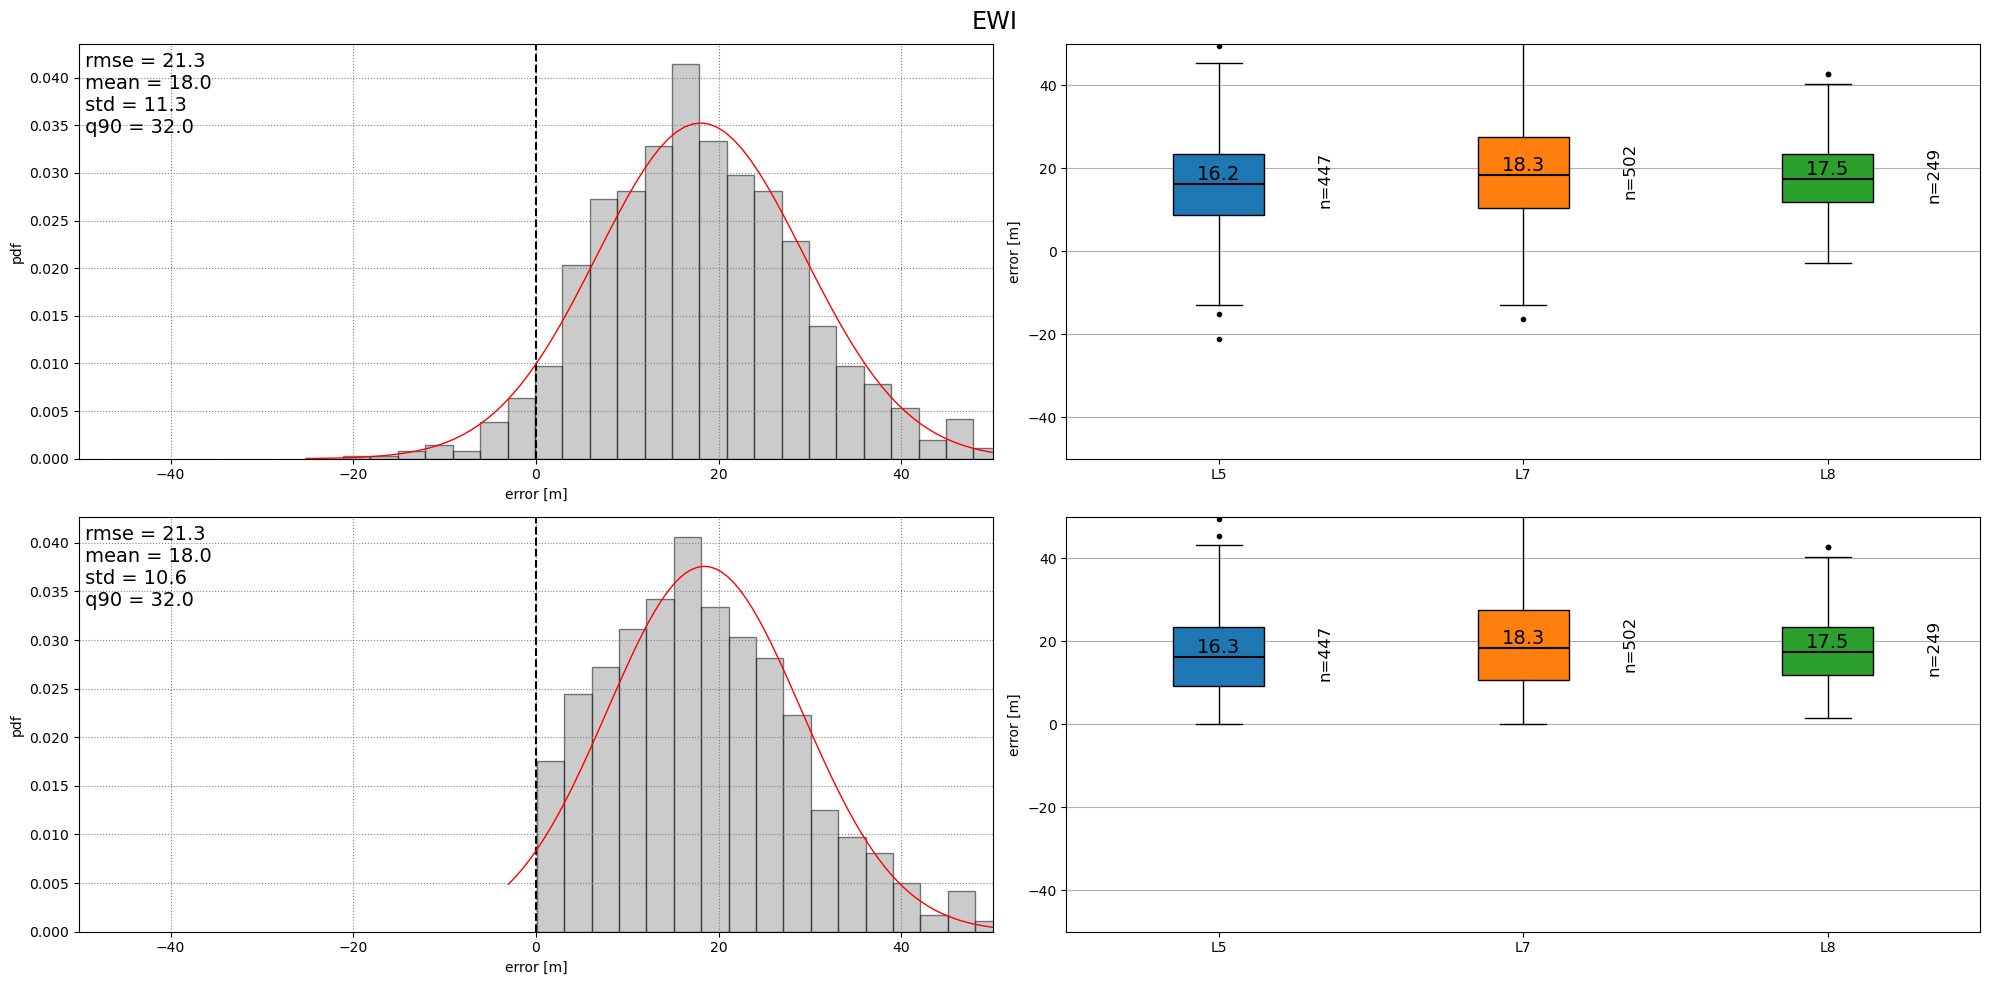

In [31]:
# calculate statistics for all transects together
chain_error = chain_sat_all - chain_sur_all        
slope, intercept, rvalue, pvalue, std_err = stats.linregress(chain_sur, chain_sat) 
R2 = rvalue**2
rmse = np.sqrt(np.mean((chain_error)**2))
mean = np.mean(chain_error)
std = np.std(chain_error)
q90 = np.percentile(np.abs(chain_error), 90)

fig, ax = plt.subplots(2, 2, figsize=(20,10), tight_layout=True)
fig.suptitle("EWI", fontsize='xx-large')
ax = ax.ravel()

# histogram
ax[0].grid(which='major',linestyle=':',color='0.5')
ax[0].axvline(x=0, ls='--', lw=1.5, color='k')
binwidth=sett['binwidth']
bins = np.arange(min(chain_error), max(chain_error) + binwidth, binwidth)
density = ax[0].hist(chain_error, bins=bins, density=True, color='0.6', edgecolor='k', alpha=0.5)
mu, std = stats.norm.fit(chain_error)
pval = stats.normaltest(chain_error)[1]
xlims = ax[0].get_xlim()
x = np.linspace(xlims[0], xlims[1], 100)
p = stats.norm.pdf(x, mu, std)
ax[0].plot(x, p, 'r-', linewidth=1)
ax[0].set(xlabel='error [m]', ylabel='pdf', xlim=sett['lims'])   
str_stats = ' rmse = %.1f\n mean = %.1f\n std = %.1f\n q90 = %.1f' % (rmse, mean, std, q90) 
ax[0].text(0, 0.98, str_stats,va='top', transform=ax[0].transAxes,fontsize=14)

# boxplot
data = []
median_data = []
n_data = []
ax[1].yaxis.grid()
for k,sat in enumerate(list(np.unique(satnames_all))):
    idx = np.where([_ == sat for _ in satnames_all])[0]
    data.append(chain_error[idx])
    median_data.append(np.median(chain_error[idx]))
    n_data.append(len(chain_error[idx]))
bp = ax[1].boxplot(data,0,'k.', labels=list(np.unique(satnames_all)), patch_artist=True)
for median in bp['medians']:
    median.set(color='k', linewidth=1.5)
for j,boxes in enumerate(bp['boxes']):
    boxes.set(facecolor='C'+str(j))
    ax[1].text(j+1,median_data[j]+1, '%.1f' % median_data[j], horizontalalignment='center', fontsize=14)
    ax[1].text(j+1+0.35,median_data[j]+1, ('n=%.d' % int(n_data[j])), ha='center', va='center', fontsize=12, rotation='vertical')
ax[1].set(ylabel='error [m]', ylim=sett['lims']);

# histogram
absolute_error = np.abs(chain_error)
ax[2].grid(which='major',linestyle=':',color='0.5')
ax[2].axvline(x=0, ls='--', lw=1.5, color='k')
binwidth=sett['binwidth']
bins = np.arange(min(absolute_error), max(absolute_error) + binwidth, binwidth)
density = ax[2].hist(absolute_error, bins=bins, density=True, color='0.6', edgecolor='k', alpha=0.5)
mu, std = stats.norm.fit(absolute_error)
pval = stats.normaltest(absolute_error)[1]
xlims = ax[2].get_xlim()
x = np.linspace(xlims[0], xlims[1], 100)
p = stats.norm.pdf(x, mu, std)
ax[2].plot(x, p, 'r-', linewidth=1)
ax[2].set(xlabel='error [m]', ylabel='pdf', xlim=sett['lims'])   
str_stats = ' rmse = %.1f\n mean = %.1f\n std = %.1f\n q90 = %.1f' % (rmse, mean, std, q90) 
ax[2].text(0, 0.98, str_stats,va='top', transform=ax[2].transAxes,fontsize=14)

# boxplot
data = []
median_data = []
n_data = []
ax[3].yaxis.grid()
for k,sat in enumerate(list(np.unique(satnames_all))):
    idx = np.where([_ == sat for _ in satnames_all])[0]
    data.append(absolute_error[idx])
    median_data.append(np.median(absolute_error[idx]))
    n_data.append(len(absolute_error[idx]))
bp = ax[3].boxplot(data,0,'k.', labels=list(np.unique(satnames_all)), patch_artist=True)
for median in bp['medians']:
    median.set(color='k', linewidth=1.5)
for j,boxes in enumerate(bp['boxes']):
    boxes.set(facecolor='C'+str(j))
    ax[3].text(j+1,median_data[j]+1, '%.1f' % median_data[j], horizontalalignment='center', fontsize=14)
    ax[3].text(j+1+0.35,median_data[j]+1, ('n=%.d' % int(n_data[j])), ha='center', va='center', fontsize=12, rotation='vertical')
ax[3].set(ylabel='error [m]', ylim=sett['lims']);

plt.show()

### Spectral Unmixing Experimentation

In [194]:
metadata['L5'].keys()

dict_keys(['filenames', 'dates', 'tilename', 'epsg', 'acc_georef', 'im_quality', 'im_dimensions'])

In [204]:
metadata['L5']['epsg'][1]

'32656'

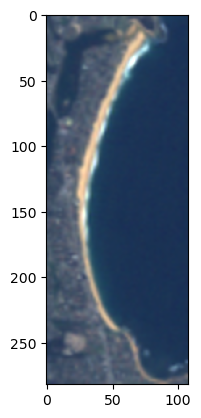

In [209]:
fns = [
    'C:\\Users\\avanever\\Documents\\CoastSatProject\\Experiments\\data\\narrabeen\\data\\L5\\ms\\1987-09-11-23-10-29_L5_089083_NARRA_ms.tif',
    'C:\\Users\\avanever\\Documents\\CoastSatProject\\Experiments\\data\\narrabeen\\data\\L5\\mask\\1987-09-11-23-10-29_L5_089083_NARRA_mask.tif'
]

im_ms, georef, cloud_mask, _, _, im_nodata = modified_coastsat.preprocess_single(
    fns, 'L5', settings['cloud_mask_issue'], settings['pan_off'], settings['s2cloudless_prob'])
im_ref_buffer = SDS_shoreline.create_shoreline_buffer(cloud_mask.shape, georef, metadata['L5']['epsg'][1], settings)

im_rgb = SDS_preprocess.rescale_image_intensity(im_ms[:,:,[2,1,0]], cloud_mask, 99.9)

plt.imshow(im_rgb)
plt.show()

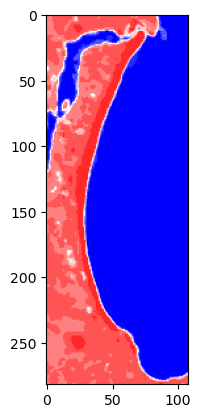

In [213]:
im_ind = indices.ensemble2(im_ms, indices.get_ensemble_list(), thresholding.otsu, cloud_mask, im_ref_buffer).reshape(im_ms.shape[:-1])
plt.imshow(im_ind, cmap='bwr')
plt.show()

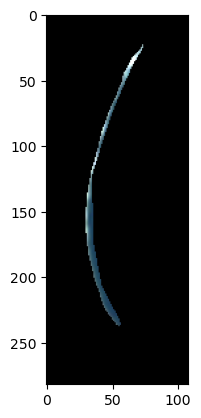

In [231]:
thresh = su.get_threshold(im_ind, {"sl_buffer": im_ref_buffer, "cloud_mask": cloud_mask})
water_mask = im_ref_buffer & ~cloud_mask & (im_ind < thresh)
water_pixels = im_ms[water_mask]
water_pixel_im = np.zeros((*im_ms.shape[:-1], 3))
water_pixel_im[water_mask] = im_rgb[water_mask]
plt.imshow(water_pixel_im)
plt.show()

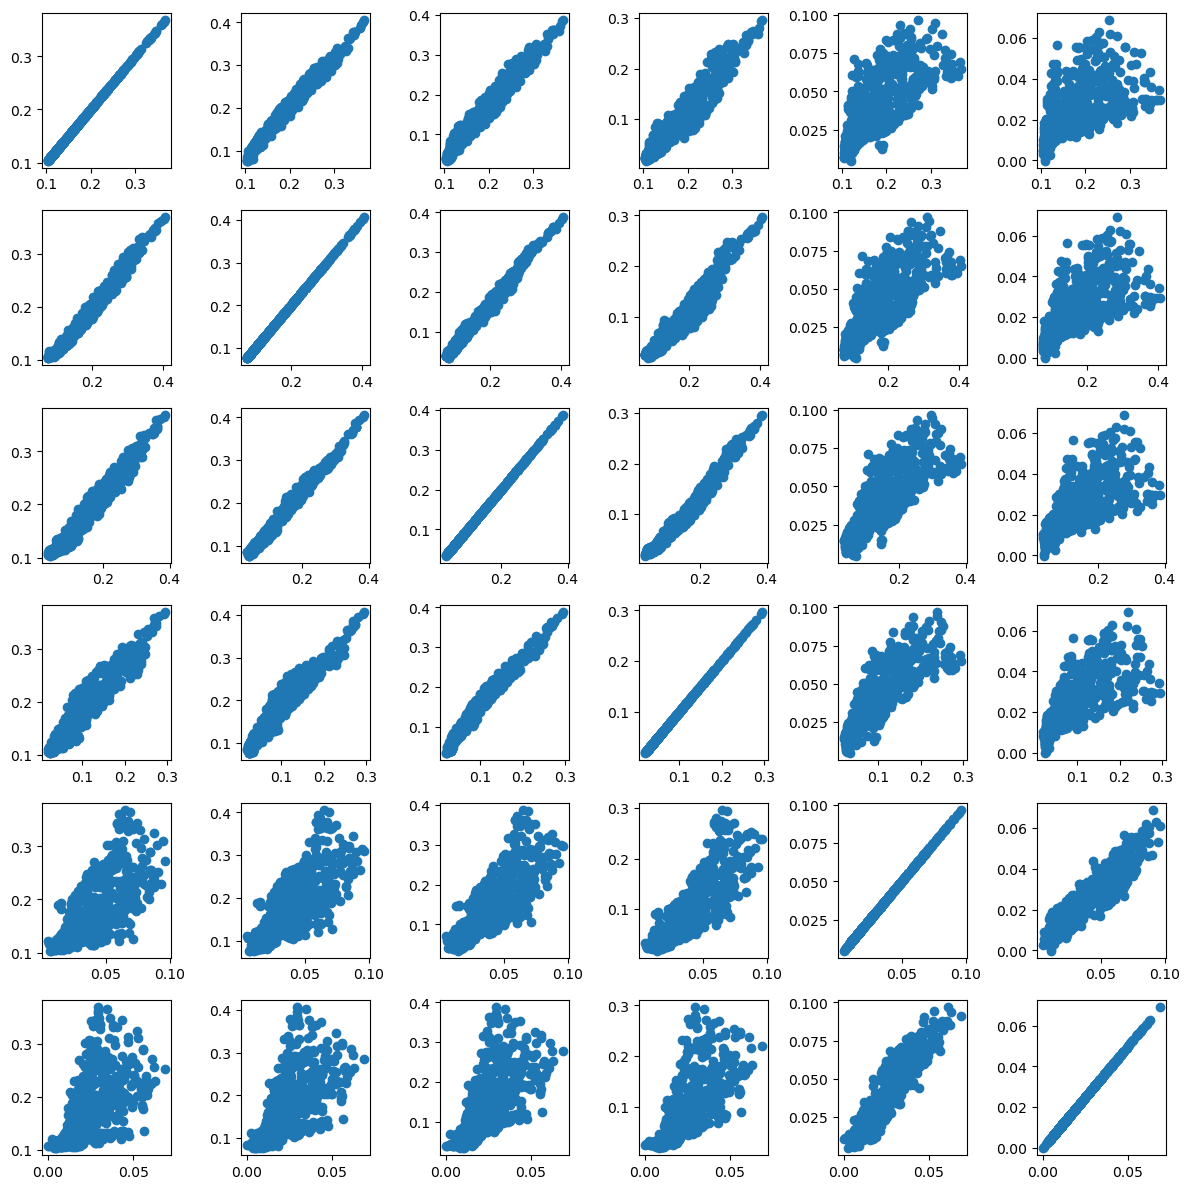

In [232]:
n_bands = im_ms.shape[-1]

# fig, axs = plt.subplots(2, 3, figsize=(12,8))
# axs = axs.ravel()
# for i in range(n_bands):
#     axs[i].hist(water_pixels[:,i], bins=128)

fig, axs = plt.subplots(n_bands, n_bands, figsize=(12, 12), tight_layout=True)
for i in range(n_bands):
    for j in range(n_bands):
        axs[i,j].scatter(water_pixels[:,i], water_pixels[:,j])

plt.show()